## IA Agéntica: De los Sistemas Basados en Reglas a los Agentes LLM
### Ejercicios Prácticos para Comprender la Evolución y el Espectro

### Bibliotecas Principales Utilizadas
- Bibliotecas estándar de Python: Sin dependencias externas, usando únicamente módulos integrados de Python
- dataclasses: Para crear objetos de datos estructurados (aunque no se utiliza intensivamente en este ejemplo)
- enum: Para definir tipos enumerados

In [3]:
"""
Agentic AI: From Rule-Based Systems to LLM Agents
Practical Exercises for Understanding the Evolution and Spectrum

This module demonstrates:
1. Rule-based systems (traditional automation)
2. Simple autonomous systems
3. Agentic systems with reasoning capabilities
4. The autonomous vs. agentic spectrum
"""

import random
import json
from datetime import datetime, timedelta
from typing import Dict, List, Any, Optional
from dataclasses import dataclass
from enum import Enum
import time

### Descripción Breve
Este código implementa un sencillo bot del clima basado en reglas que responde a las consultas del usuario utilizando reglas predefinidas de tipo si-entonces. Demuestra los sistemas de automatización tradicionales con lógica fija, sin capacidad de aprendizaje y con respuestas predecibles basadas en la coincidencia exacta de patrones.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El script crea un asistente del clima basado en reglas que procesa las consultas del usuario haciendo coincidir palabras clave con reglas predefinidas. El sistema contiene datos del clima y plantillas de respuesta codificados directamente, y usa una simple coincidencia de cadenas para determinar qué respuesta preescrita devolver según la consulta de entrada y la condición climática.

### Diagrama de Flujo Visual
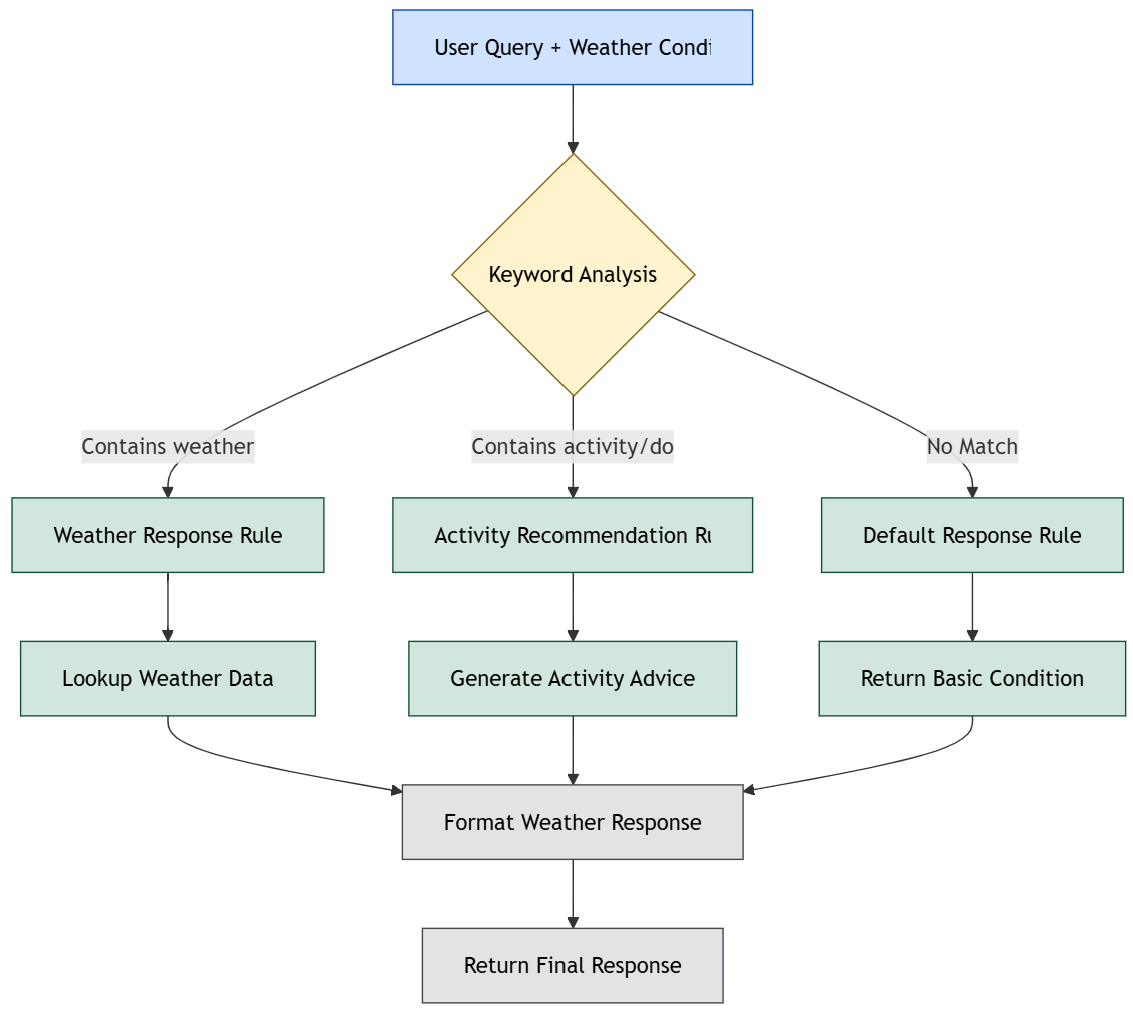

## Desglose del Código Paso a Paso
### Paso 1: Definición de la Clase del Bot del Clima Basado en Reglas

- Propósito: Crea el marco principal del sistema basado en reglas

- Componentes Clave:
  - El método __init__() inicializa un diccionario con datos del clima predefinidos, incluyendo temperatura, humedad y consejos para diferentes condiciones
  - La estructura de datos del clima contiene plantillas de respuesta completas para condiciones soleadas, lluviosas, nubladas y de tormenta

### Paso 2: Lógica de Generación de Respuestas
- Propósito: Procesa la entrada del usuario y selecciona las respuestas apropiadas según reglas fijas
- Regla 1 - Consultas del Clima:
  - Detecta la palabra clave "weather" (clima) en la entrada del usuario
  - Devuelve los datos del clima con formato desde el diccionario predefinido
  - Incluye temperatura, humedad y consejos preescritos

- Regla 2 - Planificación de Actividades:
  - Hace coincidir las palabras clave "activity" (actividad) o "do" (hacer)
  - Proporciona recomendaciones de actividades según las condiciones climáticas
  - Cada condición tiene sugerencias de actividad específicas

- Regla 3 - Respuesta por Defecto:
  - Captura todas las demás consultas que no coinciden con las reglas anteriores
  - Devuelve una declaración básica sobre la condición climática actual

### Paso 3: Demostración y Prueba
- Propósito: Muestra el sistema en acción con consultas de muestra
- Casos de Prueba:
  - Prueba el sistema con diferentes condiciones climáticas y tipos de consulta
  - Demuestra cómo la misma condición produce diferentes respuestas según el contenido de la consulta
  - Muestra la naturaleza predecible de las respuestas basadas en reglas

### Conexión con la Lección
- Comportamiento Determinista: El código ejemplifica cómo los sistemas basados en reglas siempre producen la misma salida para la misma entrada, demostrando una automatización predecible
- Adaptabilidad Limitada: Muestra la incapacidad del sistema para manejar consultas fuera de sus reglas predefinidas, ilustrando la fragilidad de la IA tradicional
- Sin Capacidad de Aprendizaje: El bot no puede mejorar ni adaptarse con el tiempo, resaltando una limitación clave de los sistemas no agénticos
- Programación Explícita: Cada comportamiento debe ser codificado explícitamente, en contraste con los sistemas de aprendizaje que pueden generalizar a partir de ejemplos
- Base para la Comparación: Proporciona una comprensión de referencia antes de introducir sistemas agénticos más avanzados con capacidades de razonamiento

In [8]:
# EXERCISE 1: RULE-BASED SYSTEM (Traditional Automation)

class RuleBasedWeatherBot:
    """
    A simple rule-based system that responds to weather queries
    using predefined if-then rules. No learning or adaptation.
    """
    
    def __init__(self):
        self.weather_data = {
            "sunny": {"temp": 25, "humidity": 40, "advice": "Great day for outdoor activities!"},
            "rainy": {"temp": 18, "humidity": 80, "advice": "Take an umbrella!"},
            "cloudy": {"temp": 20, "humidity": 60, "advice": "Perfect weather for a walk!"},
            "stormy": {"temp": 15, "humidity": 90, "advice": "Stay indoors and be safe!"}
        }
    
    def get_weather_response(self, condition: str, user_query: str) -> str:
        """Rule-based response system"""
        condition = condition.lower()
        
        # Rule 1: Direct weather query
        if "weather" in user_query.lower():
            if condition in self.weather_data:
                data = self.weather_data[condition]
                return f"It's {condition} today. Temperature: {data['temp']}°C, Humidity: {data['humidity']}%. {data['advice']}"
        
        # Rule 2: Activity planning
        elif "activity" in user_query.lower() or "do" in user_query.lower():
            if condition == "sunny":
                return "Perfect for hiking, picnic, or sports!"
            elif condition == "rainy":
                return "Good day for indoor activities like reading or movies."
            elif condition == "cloudy":
                return "Great for photography or casual walks."
            else:
                return "Best to stay indoors today."
        
        # Rule 3: Default response
        return f"The weather is {condition} today."

# Demonstration
print("\n1️⃣  RULE-BASED SYSTEM DEMONSTRATION")
print("-" * 80)
print("Characteristics: Fixed rules, no learning, predictable responses\n")

rule_bot = RuleBasedWeatherBot()

# Test different queries
queries = [
    ("sunny", "What's the weather like for outdoor activities?"),
    ("rainy", "What should I do today?"),
    ("cloudy", "Tell me about the weather")
]

for condition, query in queries:
    print(f"Query: '{query}' (Condition: {condition})")
    response = rule_bot.get_weather_response(condition, query)
    print(f"Response: {response}\n")

print("💡 Key Insight: Rule-based systems are deterministic and predictable,")
print("   but cannot adapt to new situations or learn from experience.\n")



1️⃣  RULE-BASED SYSTEM DEMONSTRATION
--------------------------------------------------------------------------------
Characteristics: Fixed rules, no learning, predictable responses

Query: 'What's the weather like for outdoor activities?' (Condition: sunny)
Response: It's sunny today. Temperature: 25°C, Humidity: 40%. Great day for outdoor activities!

Query: 'What should I do today?' (Condition: rainy)
Response: Good day for indoor activities like reading or movies.

Query: 'Tell me about the weather' (Condition: cloudy)
Response: It's cloudy today. Temperature: 20°C, Humidity: 60%. Perfect weather for a walk!

💡 Key Insight: Rule-based systems are deterministic and predictable,
   but cannot adapt to new situations or learn from experience.



### Descripción Breve
Este código implementa un sistema autónomo de gestión de tareas que prioriza y programa tareas en función de múltiples factores dinámicos. Demuestra un comportamiento orientado a objetivos con toma de decisiones adaptativa, mostrando cómo los sistemas autónomos pueden optimizar resultados sin reglas explícitas para cada escenario.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El gestor de tareas autónomo evalúa las tareas mediante un sistema de puntuación de múltiples factores que considera la urgencia, la prioridad y la eficiencia. Adapta dinámicamente su estrategia de ponderación según la presión del tiempo, crea horarios optimizados dentro de las restricciones de tiempo disponibles y genera recomendaciones inteligentes para mejorar la productividad.

### Diagrama de Flujo Visual
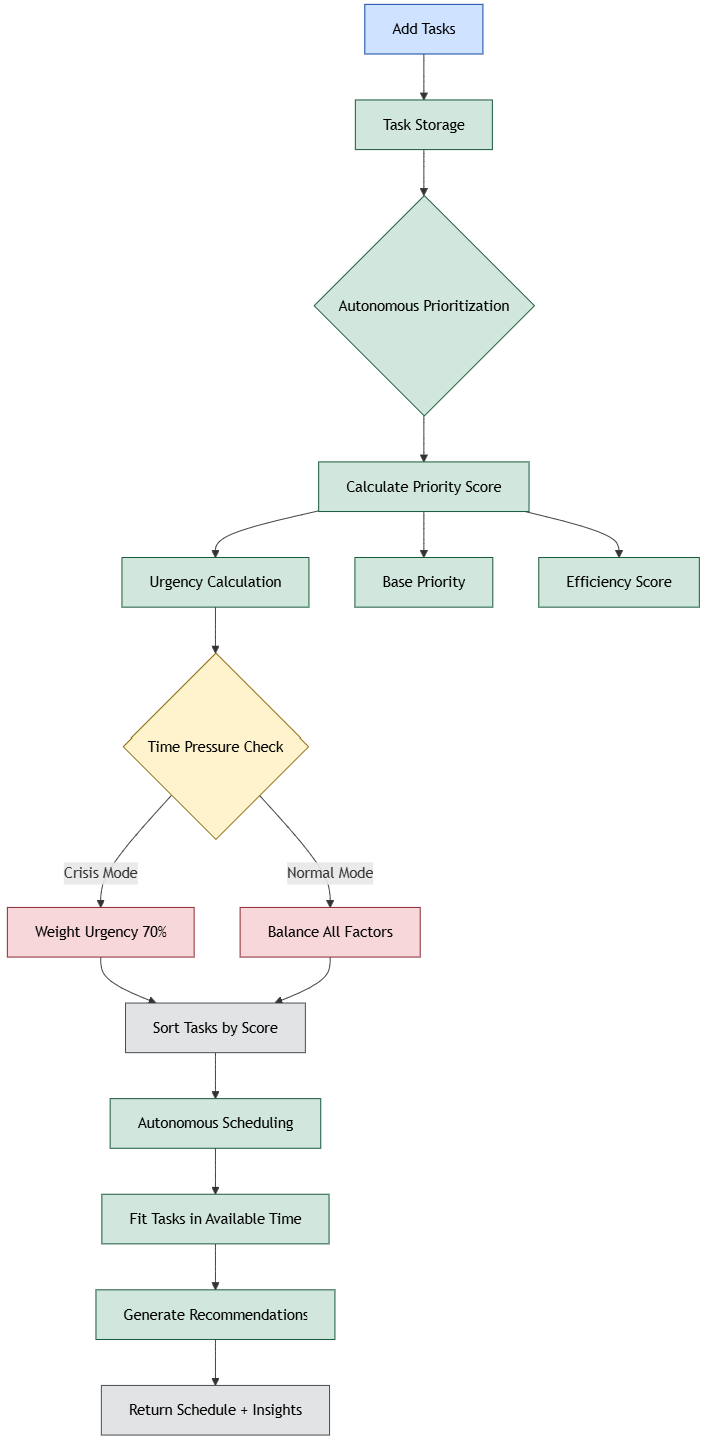

## Desglose del Código Paso a Paso
### Paso 1: Estructura de Datos de la Tarea
- Propósito: Define la unidad fundamental de trabajo con atributos completos
- Componentes Clave:
  - Identificador único y categoría para la organización
  - Nivel de prioridad y tiempo estimado requerido
  - Seguimiento de la fecha límite con objetos datetime
  - Indicador del estado de finalización

### Paso 2: Motor de Priorización Autónomo
- Propósito: Puntúa y clasifica dinámicamente las tareas usando ponderación adaptativa
- Algoritmo de Puntuación:
  - Puntuación de Urgencia: Calcula la presión del tiempo según las horas hasta la fecha límite
  - Puntuación de Prioridad: Usa el nivel de importancia inherente de la tarea
  - Puntuación de Eficiencia: Da una ligera ventaja a las tareas más cortas
- Ponderación Adaptativa:
  - Modo Crisis: Fuerte énfasis en la urgencia cuando las fechas límite son inminentes (menos de 2 horas)
  - Modo Normal: Enfoque equilibrado que considera todos los factores durante la operación regular

### Paso 3: Sistema de Programación Inteligente
- Propósito: Crea horarios optimizados dentro de las restricciones de tiempo
- Lógica de Programación:
  - Procesa las tareas en orden de prioridad a partir de la lista ordenada
  - Asigna las tareas que caben dentro del tiempo disponible restante
  - Rastrea las métricas de utilización del tiempo y eficiencia de la programación
  - Proporciona visibilidad sobre qué tareas no pudieron programarse

### Paso 4: Generación de Recomendaciones
- Propósito: Ofrece perspectivas proactivas para mejorar la gestión de tareas
- Tipos de Recomendaciones:
  - Sugerencias de utilización del tiempo para los minutos sobrantes
  - Optimización del enfoque agrupando categorías similares
  - Alertas de tareas urgentes para los elementos que no pudieron programarse
  - Consejos estratégicos basados en los patrones de carga de trabajo

### Conexión con la Lección
- Comportamiento Orientado a Objetivos: Demuestra sistemas que optimizan para objetivos en lugar de seguir reglas fijas
- Toma de Decisiones Adaptativa: Muestra cómo los sistemas autónomos pueden ajustar estrategias según condiciones cambiantes (modo crisis frente a normal)
- Optimización de Múltiples Factores: Ilustra el equilibrio entre prioridades en competencia como la urgencia, la importancia y la eficiencia
- Alcance de Razonamiento Limitado: Aunque adaptativo, el sistema no puede explicar su razonamiento ni aprender de los resultados
- Autonomía Predecible: El comportamiento es determinista según el algoritmo, careciendo de verdadera flexibilidad cognitiva
- Base para los Sistemas Agénticos: Proporciona un paso intermedio hacia sistemas más avanzados con capacidades de razonamiento y aprendizaje

In [9]:
# EXERCISE 2: AUTONOMOUS SYSTEM (Goal-directed behavior)

@dataclass
class Task:
    id: str
    priority: int
    estimated_time: int  # minutes
    deadline: datetime
    category: str
    completed: bool = False

class AutonomousTaskManager:
    """
    An autonomous system that can manage tasks, prioritize them,
    and make decisions about scheduling without explicit rules for every scenario.
    """
    
    def __init__(self):
        self.tasks: List[Task] = []
        self.current_time = datetime.now()
    
    def add_task(self, title: str, priority: int, time_needed: int, hours_until_deadline: int, category: str):
        """Add a new task to the system"""
        task = Task(
            id=title,
            priority=priority,
            estimated_time=time_needed,
            deadline=self.current_time + timedelta(hours=hours_until_deadline),
            category=category
        )
        self.tasks.append(task)
        print(f"✓ Added task: {title}")
    
    def autonomous_prioritization(self) -> List[Task]:
        """
        Autonomous decision-making for task prioritization
        Considers multiple factors and adapts to changing conditions
        """
        now = self.current_time
        available_tasks = [t for t in self.tasks if not t.completed]
        
        def priority_score(task: Task) -> float:
            # Time pressure (urgency)
            time_left = (task.deadline - now).total_seconds() / 3600  # hours
            urgency_score = max(0, 10 - time_left) / 10
            
            # Base priority
            priority_score = task.priority / 10
            
            # Efficiency (shorter tasks get slight boost)
            efficiency_score = (120 - min(task.estimated_time, 120)) / 120 * 0.3
            
            # Combined score with adaptive weighting
            if time_left < 2:  # Crisis mode
                return urgency_score * 0.7 + priority_score * 0.3
            else:  # Normal mode
                return priority_score * 0.5 + urgency_score * 0.3 + efficiency_score * 0.2
        
        return sorted(available_tasks, key=priority_score, reverse=True)
    
    def autonomous_schedule(self, available_hours: int) -> Dict[str, Any]:
        """
        Autonomously create a schedule based on available time and task priorities
        """
        prioritized_tasks = self.autonomous_prioritization()
        scheduled_tasks = []
        remaining_minutes = available_hours * 60
        
        for task in prioritized_tasks:
            if remaining_minutes >= task.estimated_time:
                scheduled_tasks.append(task)
                remaining_minutes -= task.estimated_time
        
        return {
            "scheduled_tasks": scheduled_tasks,
            "total_time_used": (available_hours * 60) - remaining_minutes,
            "efficiency": len(scheduled_tasks) / len(prioritized_tasks) if prioritized_tasks else 0,
            "recommendations": self._generate_recommendations(scheduled_tasks, remaining_minutes)
        }
    
    def _generate_recommendations(self, scheduled: List[Task], remaining_time: int) -> List[str]:
        """Generate autonomous recommendations"""
        recommendations = []
        
        if remaining_time > 30:
            recommendations.append(f"You have {remaining_time} minutes free - consider tackling smaller tasks")
        
        categories = set(task.category for task in scheduled)
        if len(categories) > 3:
            recommendations.append("Consider grouping similar tasks together for better focus")
        
        urgent_unscheduled = [t for t in self.tasks if not t.completed and t not in scheduled and 
                             (t.deadline - self.current_time).total_seconds() < 7200]  # 2 hours
        if urgent_unscheduled:
            recommendations.append(f"Warning: {len(urgent_unscheduled)} urgent tasks couldn't be scheduled")
        
        return recommendations

# Demonstration
print("\n2️⃣  AUTONOMOUS SYSTEM DEMONSTRATION")
print("-" * 80)
print("Characteristics: Goal-directed, some adaptation, limited reasoning\n")

task_manager = AutonomousTaskManager()

# Add sample tasks
print("Adding tasks to the system:")
task_manager.add_task("Prepare presentation", 8, 120, 4, "work")
task_manager.add_task("Review documents", 6, 60, 8, "work")
task_manager.add_task("Team meeting", 9, 60, 2, "meeting")
task_manager.add_task("Email responses", 4, 30, 12, "communication")
task_manager.add_task("Code review", 7, 45, 6, "work")

# Generate autonomous schedule
print("\n📅 Generating autonomous schedule for 6 hours available time...\n")
schedule = task_manager.autonomous_schedule(6)

print(f"📊 Scheduling Results:")
print(f"   Tasks scheduled: {len(schedule['scheduled_tasks'])}/{len(task_manager.tasks)}")
print(f"   Time utilized: {schedule['total_time_used']} minutes")
print(f"   Efficiency: {schedule['efficiency']:.2%}")

print(f"\n📋 Scheduled Tasks (in priority order):")
for i, task in enumerate(schedule['scheduled_tasks'], 1):
    print(f"   {i}. {task.id} ({task.estimated_time} min, Priority: {task.priority})")

print(f"\n💡 Autonomous Recommendations:")
for rec in schedule['recommendations']:
    print(f"   • {rec}")

print("\n💡 Key Insight: Autonomous systems can adapt to changing conditions and")
print("   optimize for goals, but reasoning capabilities are still limited.\n")


2️⃣  AUTONOMOUS SYSTEM DEMONSTRATION
--------------------------------------------------------------------------------
Characteristics: Goal-directed, some adaptation, limited reasoning

Adding tasks to the system:
✓ Added task: Prepare presentation
✓ Added task: Review documents
✓ Added task: Team meeting
✓ Added task: Email responses
✓ Added task: Code review

📅 Generating autonomous schedule for 6 hours available time...

📊 Scheduling Results:
   Tasks scheduled: 5/5
   Time utilized: 315 minutes
   Efficiency: 100.00%

📋 Scheduled Tasks (in priority order):
   1. Team meeting (60 min, Priority: 9)
   2. Prepare presentation (120 min, Priority: 8)
   3. Code review (45 min, Priority: 7)
   4. Review documents (60 min, Priority: 6)
   5. Email responses (30 min, Priority: 4)

💡 Autonomous Recommendations:
   • You have 45 minutes free - consider tackling smaller tasks

💡 Key Insight: Autonomous systems can adapt to changing conditions and
   optimize for goals, but reasoning capabili

### Descripción Breve
Este código implementa un asistente personal agéntico avanzado que demuestra capacidades de razonamiento, planificación, uso de herramientas y aprendizaje continuo. Muestra cómo los sistemas agénticos pueden comprender el contexto, crear planes de ejecución adaptativos, utilizar herramientas especializadas y mejorar mediante la memoria y el reconocimiento de patrones.

### Lógica del Código y Flujo: Visión General de Alto Nivel
El sistema agéntico procesa las solicitudes del usuario a través de un pipeline de múltiples etapas que incluye la comprensión de la intención, la creación dinámica de planes, la ejecución basada en herramientas y el aprendizaje continuo. Adapta su comportamiento según la urgencia, el contexto y las interacciones pasadas, demostrando verdaderas capacidades de razonamiento que van más allá del simple seguimiento de reglas.

### Diagrama de Flujo Visual
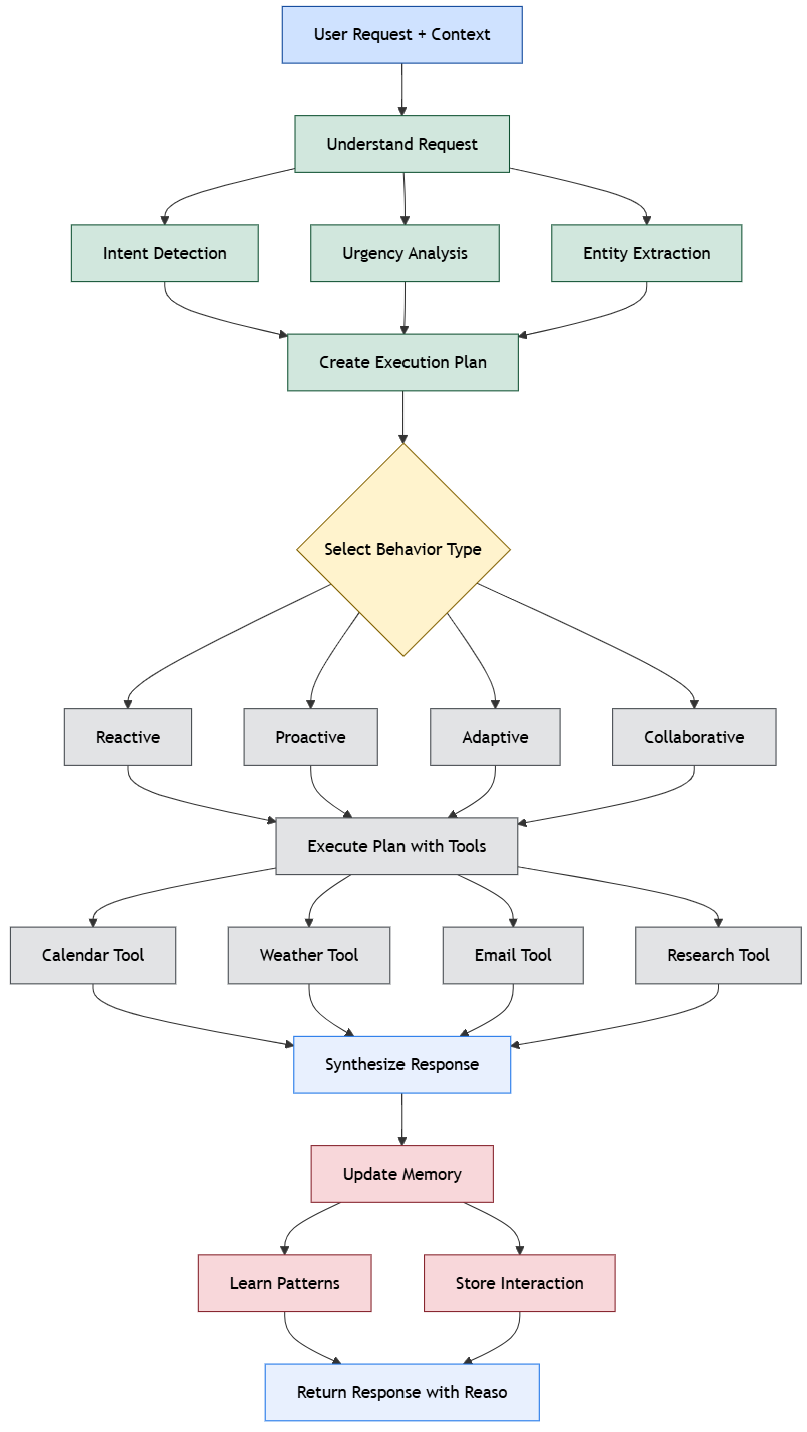

## Desglose del Código Paso a Paso
### Paso 1: Comprensión de la Solicitud y Razonamiento
- Propósito: Analiza la entrada del usuario para determinar la intención, la urgencia y los elementos contextuales
- Componentes Clave:
  - Detección de Intención: Mapea las consultas del usuario a categorías predefinidas usando coincidencia de palabras clave
  - Evaluación de la Urgencia: Identifica solicitudes sensibles al tiempo mediante indicadores de urgencia
  - Extracción de Entidades: Extrae información específica como horas, fechas y ubicaciones
  - Integración del Contexto: Combina la entrada del usuario con el contexto externo para una comprensión integral

### Paso 2: Creación Dinámica de Planes
- Propósito: Genera planes de ejecución a medida según la solicitud analizada
- Lógica de Planificación:
  - Planes Específicos por Intención: Crea diferentes secuencias de pasos para tareas de programación, clima, correo electrónico e investigación
  - Selección del Tipo de Comportamiento: Elige entre enfoques reactivo, proactivo, adaptativo o colaborativo
  - Adaptación a la Urgencia: Modifica los planes para solicitudes de alta prioridad añadiendo pasos de priorización
  - Asignación de Herramientas: Identifica qué herramientas especializadas se necesitan para cada paso del plan

### Paso 3: Ejecución del Plan con Integración de Herramientas
- Propósito: Lleva a cabo los pasos planificados usando las herramientas y el razonamiento apropiados
- Proceso de Ejecución:
  - Orquestación de Herramientas: Coordina múltiples herramientas especializadas según los requisitos del plan
  - Integración del Razonamiento: Realiza pasos analíticos para interpretar las salidas de las herramientas y sus implicaciones
  - Puntuación de Confianza: Ajusta la confianza de la respuesta según el éxito de la ejecución y la complejidad
  - Secuenciación de Pasos: Gestiona el flujo entre los diferentes pasos de ejecución

### Paso 4: Síntesis de la Respuesta y Aprendizaje
- Propósito: Crea las respuestas finales y actualiza el conocimiento del sistema
- Síntesis y Aprendizaje:
  - Respuestas Adaptadas al Comportamiento: Ajusta el estilo de la respuesta según el tipo de comportamiento seleccionado
  - Actualizaciones de Memoria: Almacena los detalles de la interacción para referencia futura y reconocimiento de patrones
  - Aprendizaje de Patrones: Rastrea la frecuencia y el éxito de los diferentes tipos de intención
  - Mejora Continua: Usa las interacciones pasadas para mejorar el rendimiento futuro

### Conexión con la Lección
- Cadena de Razonamiento Compleja: Demuestra un procesamiento cognitivo de múltiples pasos que va más allá del simple mapeo de entrada-salida
- Uso y Orquestación de Herramientas: Muestra cómo los sistemas agénticos pueden aprovechar herramientas externas y coordinar su uso
- Planificación Adaptativa: Ilustra la generación dinámica de planes que cambian según el contexto y la urgencia
- Memoria y Aprendizaje: Ejemplifica cómo los agentes acumulan conocimiento y mejoran con el tiempo
- Flexibilidad de Comportamiento: Muestra diferentes modos agénticos (reactivo, proactivo, adaptativo, colaborativo)
- Razonamiento Transparente: Proporciona visibilidad sobre el proceso de pensamiento a través de las cadenas de razonamiento
- Calibración de la Confianza: Demuestra cómo los agentes pueden evaluar y comunicar sus niveles de certeza
- Conciencia Contextual: Resalta la importancia de comprender el contexto más amplio más allá de las solicitudes inmediatas

In [5]:
# EXERCISE 3: AGENTIC SYSTEM (Reasoning, Planning, Tool Use)

class AgenticBehaviorType(Enum):
    REACTIVE = "reactive"
    PROACTIVE = "proactive"
    COLLABORATIVE = "collaborative"
    ADAPTIVE = "adaptive"

class AgenticPersonalAssistant:
    """
    An agentic system that demonstrates reasoning, planning, memory,
    and tool use capabilities. Can adapt its behavior and learn from interactions.
    """
    
    def __init__(self):
        self.memory = {
            "user_preferences": {},
            "past_interactions": [],
            "learned_patterns": {},
            "context_history": []
        }
        self.tools = {
            "calendar": self._calendar_tool,
            "weather": self._weather_tool,
            "email": self._email_tool,
            "research": self._research_tool
        }
        self.reasoning_chain = []
    
    def process_request(self, user_input: str, context: Dict[str, Any] = None) -> Dict[str, Any]:
        """
        Agentic processing with reasoning, planning, and tool selection
        """
        self.reasoning_chain = []
        context = context or {}
        
        # Step 1: Understand and reason about the request
        understanding = self._understand_request(user_input, context)
        
        # Step 2: Plan approach (agentic planning)
        plan = self._create_plan(understanding)
        
        # Step 3: Execute plan with tool use
        results = self._execute_plan(plan)
        
        # Step 4: Learn and adapt
        self._update_memory(user_input, understanding, results)
        
        return {
            "response": results["final_response"],
            "reasoning_chain": self.reasoning_chain,
            "tools_used": results["tools_used"],
            "confidence": results["confidence"],
            "learned_something": results["learned_something"]
        }
    
    def _understand_request(self, user_input: str, context: Dict[str, Any]) -> Dict[str, Any]:
        """Reasoning about user intent and context"""
        self.reasoning_chain.append("🧠 Analyzing user request and context...")
        
        # Intent detection (simplified)
        intents = {
            "schedule": ["meeting", "appointment", "schedule", "calendar"],
            "weather": ["weather", "rain", "sunny", "temperature"],
            "email": ["email", "send", "message", "contact"],
            "research": ["find", "research", "information", "look up"]
        }
        
        detected_intent = "general"
        for intent, keywords in intents.items():
            if any(keyword in user_input.lower() for keyword in keywords):
                detected_intent = intent
                break
        
        # Context awareness
        urgency = "high" if any(word in user_input.lower() for word in ["urgent", "asap", "immediately"]) else "normal"
        time_sensitive = "today" in user_input.lower() or "now" in user_input.lower()
        
        understanding = {
            "intent": detected_intent,
            "urgency": urgency,
            "time_sensitive": time_sensitive,
            "entities": self._extract_entities(user_input),
            "user_context": context
        }
        
        self.reasoning_chain.append(f"📋 Detected intent: {detected_intent}, urgency: {urgency}")
        return understanding
    
    def _create_plan(self, understanding: Dict[str, Any]) -> Dict[str, Any]:
        """Agentic planning based on understanding"""
        self.reasoning_chain.append("🎯 Creating execution plan...")
        
        intent = understanding["intent"]
        plan = {"steps": [], "tools_needed": [], "behavior_type": AgenticBehaviorType.REACTIVE}
        
        if intent == "schedule":
            plan["steps"] = ["check_calendar", "find_free_slots", "suggest_times", "book_if_confirmed"]
            plan["tools_needed"] = ["calendar"]
            plan["behavior_type"] = AgenticBehaviorType.PROACTIVE
            
        elif intent == "weather":
            plan["steps"] = ["get_weather", "analyze_implications", "provide_recommendations"]
            plan["tools_needed"] = ["weather"]
            
        elif intent == "email":
            plan["steps"] = ["draft_email", "check_contacts", "send_or_suggest"]
            plan["tools_needed"] = ["email"]
            
        elif intent == "research":
            plan["steps"] = ["search_information", "synthesize_findings", "present_summary"]
            plan["tools_needed"] = ["research"]
            plan["behavior_type"] = AgenticBehaviorType.ADAPTIVE
            
        else:
            plan["steps"] = ["analyze_request", "provide_general_assistance"]
            plan["tools_needed"] = []
        
        # Adaptive planning based on urgency
        if understanding["urgency"] == "high":
            plan["behavior_type"] = AgenticBehaviorType.PROACTIVE
            plan["steps"] = ["prioritize_request"] + plan["steps"]
        
        self.reasoning_chain.append(f"📝 Plan: {len(plan['steps'])} steps, {len(plan['tools_needed'])} tools needed")
        return plan
    
    def _execute_plan(self, plan: Dict[str, Any]) -> Dict[str, Any]:
        """Execute the agentic plan"""
        self.reasoning_chain.append("⚡ Executing plan...")
        
        tools_used = []
        responses = []
        confidence = 0.8  # Base confidence
        
        for step in plan["steps"]:
            if step in ["check_calendar", "get_weather", "search_information"]:
                # Use appropriate tool
                tool_name = None
                if "calendar" in step: tool_name = "calendar"
                elif "weather" in step: tool_name = "weather"
                elif "search" in step: tool_name = "research"
                
                if tool_name and tool_name in self.tools:
                    result = self.tools[tool_name](step)
                    tools_used.append(tool_name)
                    responses.append(result)
                    
            elif step == "analyze_implications":
                # Reasoning step
                analysis = self._analyze_and_reason(responses[-1] if responses else {})
                responses.append(analysis)
                confidence += 0.1
                
            elif step == "prioritize_request":
                self.reasoning_chain.append("🚨 Prioritizing due to high urgency")
                confidence += 0.05
        
        # Synthesize final response
        final_response = self._synthesize_response(responses, plan["behavior_type"])
        
        return {
            "final_response": final_response,
            "tools_used": tools_used,
            "confidence": min(confidence, 1.0),
            "learned_something": len(tools_used) > 0
        }
    
    def _synthesize_response(self, responses: List[Any], behavior_type: AgenticBehaviorType) -> str:
        """Synthesize responses based on agentic behavior type"""
        if not responses:
            return "I understand your request, but I need more specific information to help you effectively."
        
        base_response = str(responses[-1]) if responses else "I've processed your request."
        
        if behavior_type == AgenticBehaviorType.PROACTIVE:
            return f"{base_response} I've also anticipated your next steps and prepared some suggestions."
        elif behavior_type == AgenticBehaviorType.ADAPTIVE:
            return f"{base_response} I've learned from this interaction and will improve future responses."
        elif behavior_type == AgenticBehaviorType.COLLABORATIVE:
            return f"{base_response} Would you like me to explore this further or take any additional actions?"
        else:
            return base_response
    
    # Tool implementations (simplified)
    def _calendar_tool(self, action: str) -> str:
        return f"Calendar checked - found 3 available slots today"
    
    def _weather_tool(self, action: str) -> str:
        weather_options = ["sunny and 22°C", "cloudy with chance of rain", "partly sunny and 18°C"]
        return f"Current weather: {random.choice(weather_options)}"
    
    def _email_tool(self, action: str) -> str:
        return "Email drafted and ready to send"
    
    def _research_tool(self, action: str) -> str:
        return "Found relevant information from 5 reliable sources"
    
    def _extract_entities(self, text: str) -> Dict[str, List[str]]:
        """Simple entity extraction"""
        entities = {"times": [], "dates": [], "people": [], "locations": []}
        # Simplified implementation
        if "tomorrow" in text.lower():
            entities["dates"].append("tomorrow")
        if "3pm" in text.lower() or "15:00" in text:
            entities["times"].append("3pm")
        return entities
    
    def _analyze_and_reason(self, data: Any) -> str:
        """Reasoning component"""
        self.reasoning_chain.append("🤔 Analyzing implications and context...")
        return f"Analysis complete: {data}"
    
    def _update_memory(self, user_input: str, understanding: Dict, results: Dict):
        """Learning and memory update"""
        interaction = {
            "timestamp": datetime.now(),
            "user_input": user_input,
            "intent": understanding["intent"],
            "success": results["confidence"] > 0.7,
            "tools_used": results["tools_used"]
        }
        self.memory["past_interactions"].append(interaction)
        
        # Simple pattern learning
        intent = understanding["intent"]
        if intent in self.memory["learned_patterns"]:
            self.memory["learned_patterns"][intent] += 1
        else:
            self.memory["learned_patterns"][intent] = 1

# Demonstration
print("\n3️⃣  AGENTIC SYSTEM DEMONSTRATION")
print("-" * 80)
print("Characteristics: Complex reasoning, planning, tool use, continuous learning\n")

assistant = AgenticPersonalAssistant()

# Test multiple scenarios
scenarios = [
    ("I need to schedule an urgent meeting about the project proposal today", 
     {"user_role": "manager", "time": "morning"}),
    ("What's the weather like and should I bring an umbrella?", 
     {"location": "downtown"}),
    ("Find information about agentic AI systems", 
     {"research_level": "intermediate"})
]

for request, context in scenarios:
    print(f"📨 Request: '{request}'")
    print(f"   Context: {context}\n")
    
    result = assistant.process_request(request, context)
    
    print(f"🤖 Response: {result['response']}")
    print(f"\n🧠 Reasoning Chain:")
    for step in result['reasoning_chain']:
        print(f"   {step}")
    print(f"\n🔧 Tools Used: {', '.join(result['tools_used']) if result['tools_used'] else 'None'}")
    print(f"📊 Confidence: {result['confidence']:.2%}")
    print(f"📚 Learned: {'Yes' if result['learned_something'] else 'No'}")
    print("\n" + "-" * 80 + "\n")

print("💡 Key Insight: Agentic systems can reason about context, create plans,")
print("   use tools strategically, and learn from every interaction.\n")


3️⃣  AGENTIC SYSTEM DEMONSTRATION
--------------------------------------------------------------------------------
Characteristics: Complex reasoning, planning, tool use, continuous learning

📨 Request: 'I need to schedule an urgent meeting about the project proposal today'
   Context: {'user_role': 'manager', 'time': 'morning'}

🤖 Response: Calendar checked - found 3 available slots today I've also anticipated your next steps and prepared some suggestions.

🧠 Reasoning Chain:
   🧠 Analyzing user request and context...
   📋 Detected intent: schedule, urgency: high
   🎯 Creating execution plan...
   📝 Plan: 5 steps, 1 tools needed
   ⚡ Executing plan...
   🚨 Prioritizing due to high urgency

🔧 Tools Used: calendar
📊 Confidence: 85.00%
📚 Learned: Yes

--------------------------------------------------------------------------------

📨 Request: 'What's the weather like and should I bring an umbrella?'
   Context: {'location': 'downtown'}

🤖 Response: Analysis complete: Current weather: su

### Descripción Breve
Este código demuestra el espectro evolutivo de los sistemas de IA comparando cómo los enfoques basados en reglas, autónomos y agénticos manejan el mismo escenario. Ilustra la progresión desde la simple coincidencia de patrones hasta el razonamiento complejo, resaltando las diferencias clave en flexibilidad, adaptabilidad y capacidades cognitivas a lo largo del espectro de madurez de la IA.

### Lógica del Código y Flujo: Visión General de Alto Nivel
La demostración del espectro crea un marco de comparación unificado que procesa el mismo escenario de entrada a través de tres arquitecturas de sistemas de IA distintas. Evalúa y contrasta sistemáticamente sus respuestas, y luego proporciona una tabla de análisis completa que resalta las diferencias clave de capacidad en flexibilidad, razonamiento, adaptabilidad, conciencia contextual y aprendizaje.

### Diagrama de Flujo Visual
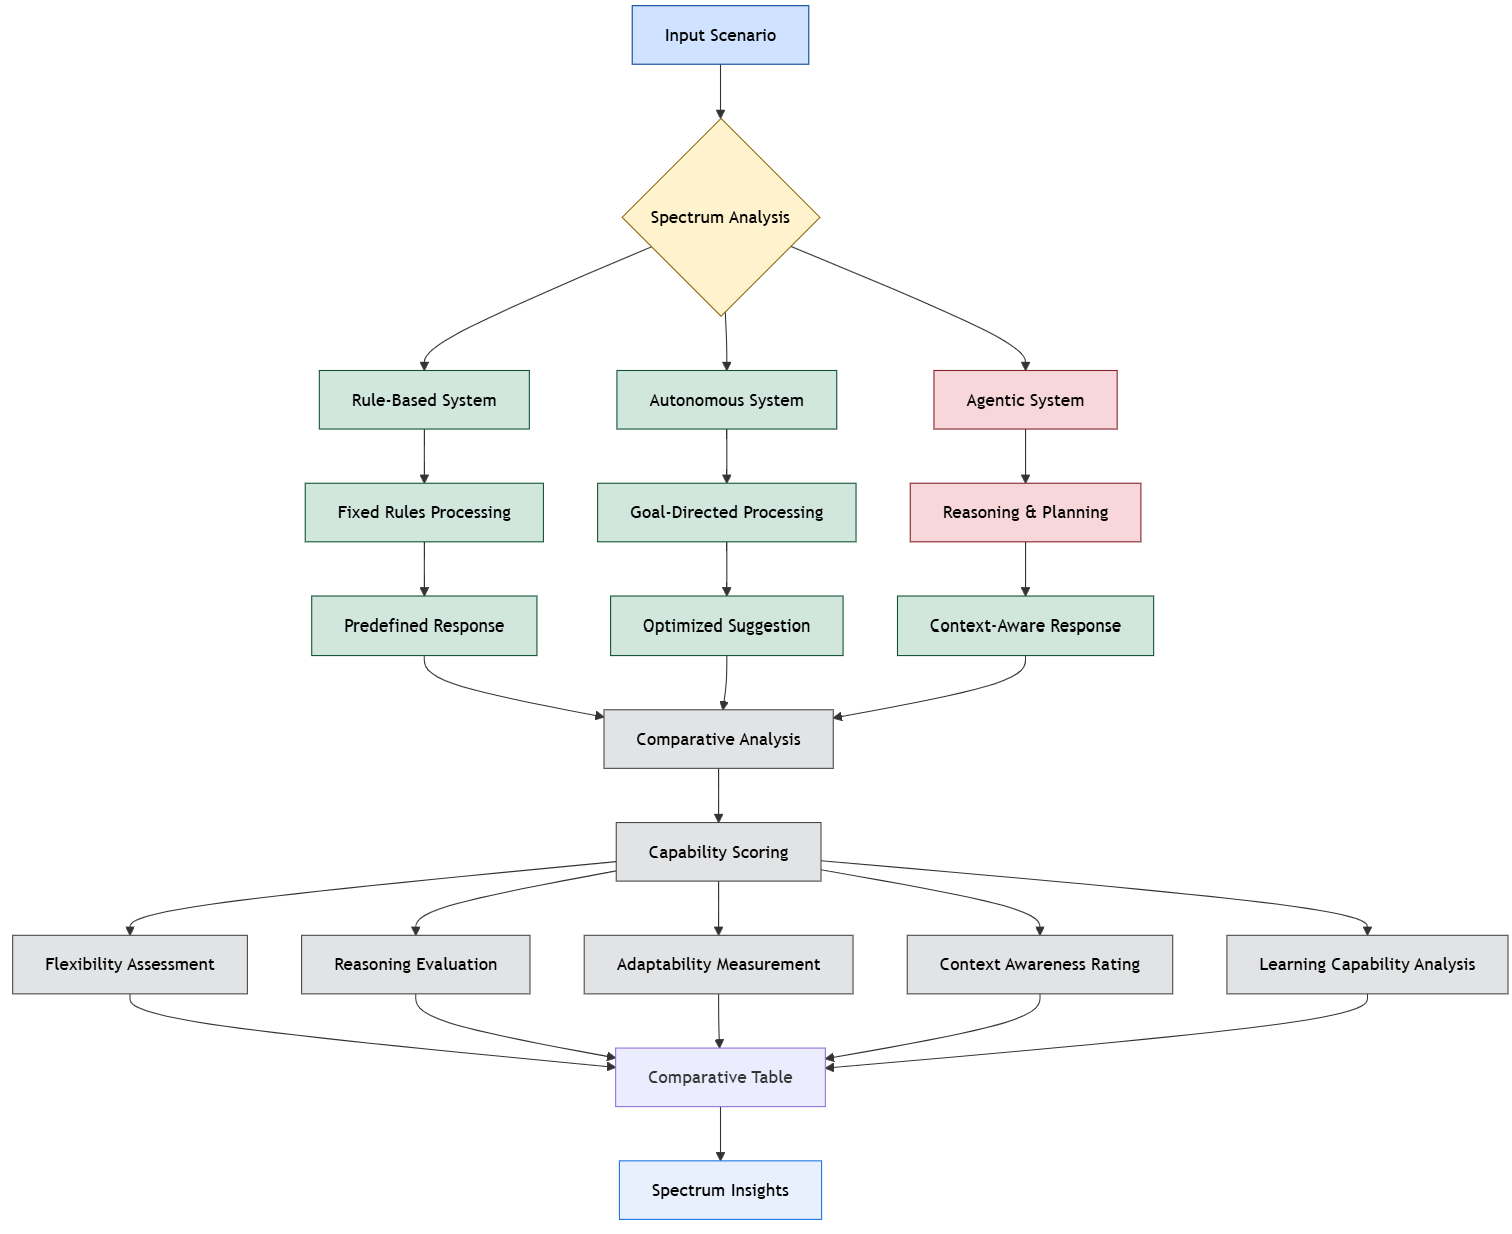

## Desglose del Código Paso a Paso
### Paso 1: Inicialización del Marco del Espectro
- Propósito: Crea un entorno de pruebas unificado que contiene los tres tipos de sistemas de IA
- Integración de Sistemas:
  - Instancia el bot del clima basado en reglas para la coincidencia básica de patrones
  - Inicializa el gestor de tareas autónomo para el procesamiento orientado a objetivos
  - Configura el asistente personal agéntico para capacidades de razonamiento avanzadas
  - Establece una interfaz común para el análisis comparativo

### Paso 2: Pipeline de Procesamiento de Escenarios
- Propósito: Enruta el mismo escenario de entrada a través de cada tipo de sistema para su procesamiento en paralelo
- Ejecución de Múltiples Sistemas:
  - Vía Basada en Reglas: Aplica reglas fijas si-entonces sin adaptación ni consideración del contexto
  - Vía Autónoma: Usa optimización orientada a objetivos pero permanece dentro de los límites programados
  - Vía Agéntica: Activa cadenas de razonamiento complejas, selección de herramientas y adaptación contextual
  - Recopilación de Respuestas: Captura las salidas de cada tipo de sistema para el análisis comparativo

### Paso 3: Análisis del Espectro de Capacidades
- Propósito: Evalúa y puntúa sistemáticamente cada sistema a lo largo de las dimensiones clave de capacidad de la IA
- Dimensiones de Evaluación:
  - Flexibilidad: Capacidad para manejar entradas variadas y escenarios inesperados
  - Razonamiento: Profundidad del procesamiento cognitivo, desde nulo hasta razonamiento complejo de múltiples pasos
  - Adaptabilidad: Capacidad para ajustar el comportamiento según nueva información o condiciones cambiantes
  - Conciencia Contextual: Consideración de factores situacionales más allá de la solicitud inmediata
  - Aprendizaje: Mejora con el tiempo a través de la experiencia y el reconocimiento de patrones

### Paso 4: Visualización Comparativa
- Propósito: Presenta el análisis en un formato fácil de comprender
- Enfoque de Presentación:
  - Comparación de respuestas lado a lado que muestra las diferencias concretas de salida
  - Tabla de capacidades estructurada con una progresión clara de lo básico a lo avanzado
  - Formato visual que enfatiza la naturaleza de espectro de la evolución de la IA
  - Síntesis de perspectivas que conecta las capacidades técnicas con las implicaciones prácticas

### Conexión con la Lección
- Progresión Evolutiva: Demuestra la clara trayectoria desde la simple automatización hasta la agencia inteligente
- Compromisos de Capacidad: Muestra la relación entre la complejidad del sistema y los requisitos de implementación
- Espectro de Razonamiento: Ilustra el continuo desde la ausencia de razonamiento hasta el procesamiento cognitivo complejo de múltiples pasos
- Escala de Adaptabilidad: Resalta cómo los sistemas evolucionan desde patrones de comportamiento rígidos hacia flexibles
- Integración del Contexto: Muestra la progresión desde el procesamiento que ignora el contexto hasta el que es consciente de él
- Dimensión del Aprendizaje: Demuestra el cambio de sistemas estáticos a sistemas en mejora continua
- Implementación Práctica: Conecta los conceptos teóricos de IA con arquitecturas de sistemas concretas
- Criterios de Selección de Sistemas: Proporciona un marco para elegir los enfoques de IA apropiados según los requisitos del caso de uso

In [6]:
# EXERCISE 4: AUTONOMOUS vs AGENTIC SPECTRUM DEMONSTRATION

class AutonomousVsAgenticSpectrum:
    """
    Demonstrates the spectrum from autonomous to agentic behavior
    """
    
    def __init__(self):
        self.rule_based = RuleBasedWeatherBot()
        self.autonomous = AutonomousTaskManager()
        self.agentic = AgenticPersonalAssistant()
    
    def demonstrate_spectrum(self, scenario: str) -> Dict[str, Any]:
        """
        Show how different system types handle the same scenario
        """
        results = {
            "scenario": scenario,
            "rule_based_response": None,
            "autonomous_response": None,
            "agentic_response": None,
            "spectrum_analysis": {}
        }
        
        if "weather" in scenario.lower():
            # Rule-based: Fixed rules
            results["rule_based_response"] = self.rule_based.get_weather_response("sunny", scenario)
            
            # Autonomous: Goal-directed but limited reasoning
            results["autonomous_response"] = "Autonomous system would check weather API and make activity suggestions based on programmed goals"
            
            # Agentic: Reasoning, context awareness, planning
            results["agentic_response"] = self.agentic.process_request(scenario)
        
        # Analyze the spectrum
        results["spectrum_analysis"] = {
            "rule_based": {
                "flexibility": "Low",
                "reasoning": "None",
                "adaptability": "None",
                "context_awareness": "Limited",
                "learning": "None"
            },
            "autonomous": {
                "flexibility": "Medium",
                "reasoning": "Goal-directed",
                "adaptability": "Limited",
                "context_awareness": "Some",
                "learning": "Minimal"
            },
            "agentic": {
                "flexibility": "High",
                "reasoning": "Complex",
                "adaptability": "High",
                "context_awareness": "Extensive",
                "learning": "Continuous"
            }
        }
        
        return results

# Demonstration
print("\n4️⃣  AUTONOMOUS vs AGENTIC SPECTRUM")
print("-" * 80)
print("Comparing how different system types handle the same scenario\n")

spectrum = AutonomousVsAgenticSpectrum()
scenario = "What's the weather like and what should I do today?"

print(f"🎯 Scenario: '{scenario}'\n")

comparison = spectrum.demonstrate_spectrum(scenario)

print("📊 SYSTEM COMPARISON:")
print("\n1. RULE-BASED RESPONSE:")
print(f"   {comparison['rule_based_response']}")

print("\n2. AUTONOMOUS RESPONSE:")
print(f"   {comparison['autonomous_response']}")

print("\n3. AGENTIC RESPONSE:")
agentic_result = comparison['agentic_response']
print(f"   {agentic_result['response']}")

print("\n\n📈 SPECTRUM ANALYSIS:")
print("-" * 80)

# Create comparison table
aspects = ["flexibility", "reasoning", "adaptability", "context_awareness", "learning"]
systems = ["rule_based", "autonomous", "agentic"]

print(f"{'Aspect':<20} {'Rule-Based':<15} {'Autonomous':<15} {'Agentic':<15}")
print("-" * 65)

for aspect in aspects:
    row = f"{aspect.replace('_', ' ').title():<20}"
    for system in systems:
        value = comparison['spectrum_analysis'][system][aspect]
        row += f"{value:<15}"
    print(row)

print("\n💡 Key Insight: The spectrum represents increasing sophistication in")
print("   decision-making, from fixed rules to adaptive reasoning.\n")


4️⃣  AUTONOMOUS vs AGENTIC SPECTRUM
--------------------------------------------------------------------------------
Comparing how different system types handle the same scenario

🎯 Scenario: 'What's the weather like and what should I do today?'

📊 SYSTEM COMPARISON:

1. RULE-BASED RESPONSE:
   It's sunny today. Temperature: 25°C, Humidity: 40%. Great day for outdoor activities!

2. AUTONOMOUS RESPONSE:
   Autonomous system would check weather API and make activity suggestions based on programmed goals

3. AGENTIC RESPONSE:
   Analysis complete: Current weather: cloudy with chance of rain


📈 SPECTRUM ANALYSIS:
--------------------------------------------------------------------------------
Aspect               Rule-Based      Autonomous      Agentic        
-----------------------------------------------------------------
Flexibility         Low            Medium         High           
Reasoning           None           Goal-directed  Complex        
Adaptability        None        

In [7]:
# STUDENT EXERCISES

exercises_text = """
📚 EXERCISE SET 1: SYSTEM EVOLUTION

1. Extend the RuleBasedWeatherBot with 5 more weather conditions and rules
   - Add conditions like: foggy, windy, snowy, hot, cold
   - Create specific rules for each condition
   - Test edge cases and rule conflicts

2. Add emotion detection to make responses more contextual
   - Detect user mood from input text
   - Adjust response tone accordingly
   - Handle multiple emotions in one query

3. What are the limitations you encounter?
   - Document scenarios where rules break down
   - Identify when you need more sophisticated reasoning
   - Consider scalability issues

📚 EXERCISE SET 2: AUTONOMOUS BEHAVIOR

1. Add a learning mechanism to the AutonomousTaskManager
   - Track task completion times vs. estimates
   - Adjust future time estimates based on history
   - Adapt priority calculations based on success patterns

2. Implement conflict resolution when tasks have scheduling conflicts
   - Detect overlapping time slots
   - Propose alternative schedules
   - Allow for task rescheduling

3. Add resource constraints
   - Energy levels throughout the day
   - Availability of required tools or people
   - Budget constraints for certain task categories

📚 EXERCISE SET 3: AGENTIC CAPABILITIES

1. Implement a multi-step planning system for complex projects
   - Break down large projects into subtasks
   - Create dependencies between tasks
   - Handle dynamic replanning when conditions change

2. Add memory persistence and retrieval based on context
   - Save memory to file/database
   - Retrieve relevant past interactions
   - Use context to inform current decisions

3. Create a collaborative mode with clarifying questions
   - Identify ambiguous requests
   - Generate relevant clarifying questions
   - Incorporate user answers into planning

📚 EXERCISE SET 4: SPECTRUM ANALYSIS

1. Create your own scenario and compare all three system types
   - Choose a domain (healthcare, education, e-commerce, etc.)
   - Implement basic versions of each system type
   - Compare their responses and capabilities

2. Design a hybrid system combining autonomous and agentic features
   - Identify which features from each type are most valuable
   - Create a balanced architecture
   - Test on various scenarios

3. Identify real-world applications for each level of the spectrum
   - When is a rule-based system sufficient?
   - When do you need autonomous capabilities?
   - When are full agentic capabilities required?

💡 REFLECTION QUESTIONS:

• When might you prefer a rule-based system over an agentic one?
  Consider: predictability, debugging, compliance, simplicity

• How does the complexity of the problem domain affect system choice?
  Consider: number of edge cases, need for adaptation, context importance

• What are the tradeoffs between predictability and flexibility?
  Consider: safety-critical applications, user trust, explainability

• How would you measure the effectiveness of each system type?
  Consider: accuracy, response time, user satisfaction, adaptability

• What ethical considerations arise with increasingly agentic systems?
  Consider: autonomy, transparency, accountability, bias
  """
print(exercises_text)


📚 EXERCISE SET 1: SYSTEM EVOLUTION

1. Extend the RuleBasedWeatherBot with 5 more weather conditions and rules
   - Add conditions like: foggy, windy, snowy, hot, cold
   - Create specific rules for each condition
   - Test edge cases and rule conflicts

2. Add emotion detection to make responses more contextual
   - Detect user mood from input text
   - Adjust response tone accordingly
   - Handle multiple emotions in one query

3. What are the limitations you encounter?
   - Document scenarios where rules break down
   - Identify when you need more sophisticated reasoning
   - Consider scalability issues

📚 EXERCISE SET 2: AUTONOMOUS BEHAVIOR

1. Add a learning mechanism to the AutonomousTaskManager
   - Track task completion times vs. estimates
   - Adjust future time estimates based on history
   - Adapt priority calculations based on success patterns

2. Implement conflict resolution when tasks have scheduling conflicts
   - Detect overlapping time slots
   - Propose alternative 